In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

print("DuckDB version:", duckdb.__version__)
print("All good — ready to go!")

DuckDB version: 1.5.2
All good — ready to go!


In [3]:
import duckdb
import os

# Checking pwd
print("Current directory:", os.getcwd())

df = duckdb.sql("""
    SELECT * FROM '/Users/syedamishrasaiara/pythonprojects/SQL_Analytics/data/yellow_tripdata_2024-01.parquet'
    LIMIT 5
""").df()

print(df.shape)
df.head()

#df = duckdb.sql("SELECT * FROM 'data/yellow_tripdata_2024-01.parquet' LIMIT 5").df()


Current directory: /Users/syedamishrasaiara/pythonprojects/SQL_Analytics/notebooks
(5, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,1,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,1,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,1,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,1,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [5]:
os.chdir('/Users/syedamishrasaiara/pythonprojects/SQL_Analytics')

DATA = "data/yellow_tripdata_2024-01.parquet"
print("Ready!")

Ready!


## NYC Yellow Taxi — January 2024
### Exploratory Data Analysis
This notebook explores ~3M taxi trips to understand the dataset structure, 
data quality, and surface early patterns before deeper analysis. 

In [6]:
# How many rows and what columns exist?
overview = duckdb.sql(f"""
    SELECT COUNT(*) AS total_trips,
           COUNT(DISTINCT VendorID) AS vendors,
           MIN(tpep_pickup_datetime) AS earliest_trip,
           MAX(tpep_pickup_datetime) AS latest_trip,
           ROUND(AVG(trip_distance), 2) AS avg_distance_miles,
           ROUND(AVG(fare_amount), 2) AS avg_fare_usd
    FROM '{DATA}'
""").df()

overview

,total_trips,vendors,earliest_trip,latest_trip,avg_distance_miles,avg_fare_usd
0,2964624,3,2002-12-31 22:59:39,2024-02-01 00:01:15,3.65,18.18


In [7]:
# Are there data quality issues?
nulls = duckdb.sql(f"""
    SELECT
        COUNT(*) - COUNT(fare_amount) AS null_fares,
        COUNT(*) - COUNT(trip_distance) AS null_distances,
        COUNT(*) - COUNT(passenger_count) AS null_passengers,
        COUNT(*) - COUNT(tpep_pickup_datetime) AS null_pickups
    FROM '{DATA}'
""").df()

nulls

,null_fares,null_distances,null_passengers,null_pickups
0,0,0,140162,0


In [8]:
# Removing bad rows: negative fares, zero distance, 
# unrealistic passenger counts
clean = duckdb.sql(f"""
    SELECT * FROM '{DATA}'
    WHERE fare_amount > 0
      AND trip_distance > 0
      AND passenger_count BETWEEN 1 AND 6
      AND tpep_pickup_datetime >= '2024-01-01'
      AND tpep_pickup_datetime < '2024-02-01'
""").df()

print(f"Clean rows: {len(clean):,}")
print(f"Removed: {3000000 - len(clean):,} bad rows")

Clean rows: 2,723,745
Removed: 276,255 bad rows


Trips by hours

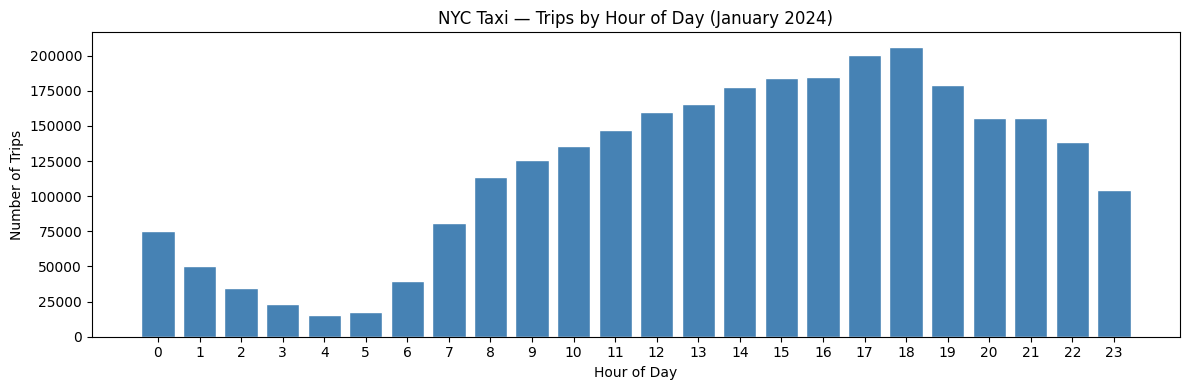

In [10]:
hourly = duckdb.sql(f"""
    SELECT EXTRACT(HOUR FROM tpep_pickup_datetime) AS hour,
           COUNT(*) AS trips
    FROM '{DATA}'
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY hour
    ORDER BY hour
""").df()

plt.figure(figsize=(12, 4))
plt.bar(hourly['hour'], hourly['trips'], color='steelblue', edgecolor='white')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('NYC Taxi — Trips by Hour of Day (January 2024)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('charts/trips_by_hour.png', dpi=150)
plt.show()

trips by day of week

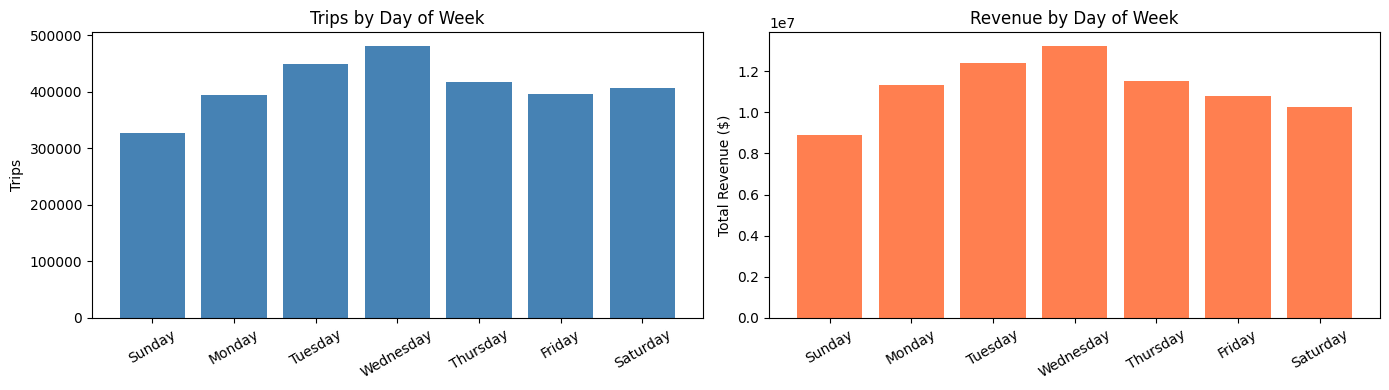

In [11]:
daily = duckdb.sql(f"""
    SELECT DAYNAME(tpep_pickup_datetime) AS day_name,
           DAYOFWEEK(tpep_pickup_datetime) AS day_num,
           COUNT(*) AS trips,
           ROUND(SUM(total_amount), 2) AS total_revenue
    FROM '{DATA}'
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY day_name, day_num
    ORDER BY day_num
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(daily['day_name'], daily['trips'], color='steelblue')
ax1.set_title('Trips by Day of Week')
ax1.set_ylabel('Trips')
ax1.tick_params(axis='x', rotation=30)

ax2.bar(daily['day_name'], daily['total_revenue'], color='coral')
ax2.set_title('Revenue by Day of Week')
ax2.set_ylabel('Total Revenue ($)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('charts/trips_by_day.png', dpi=150)
plt.show()

fare distribution

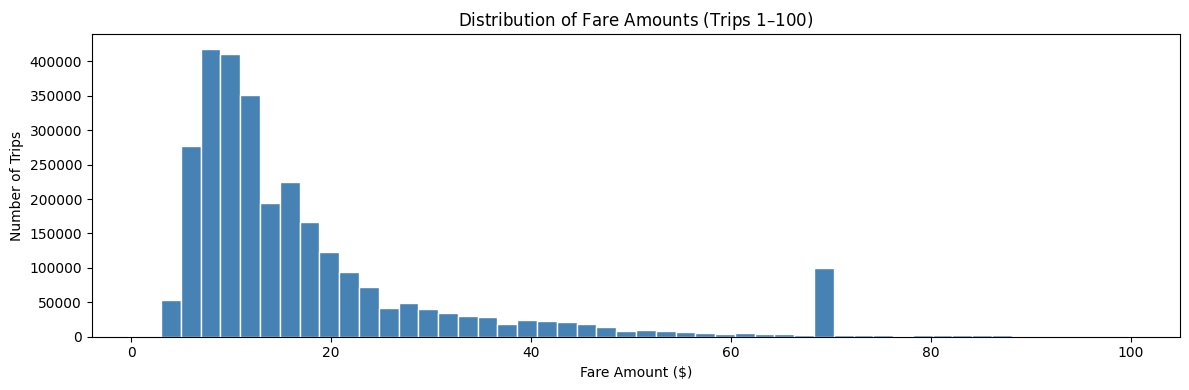

count    2917653.00
mean          18.29
std           15.84
min            1.00
25%            8.60
50%           12.80
75%           20.50
max          100.00
Name: fare_amount, dtype: float64


In [12]:
fares = duckdb.sql(f"""
    SELECT fare_amount
    FROM '{DATA}'
    WHERE fare_amount BETWEEN 1 AND 100
""").df()

plt.figure(figsize=(12, 4))
plt.hist(fares['fare_amount'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Fare Amounts (Trips $1–$100)')
plt.tight_layout()
plt.savefig('charts/fare_distribution.png', dpi=150)
plt.show()

print(fares['fare_amount'].describe().round(2))

## Key Findings from Exploration

- **Peak hours**: Demand builds steadily through the day, peaking at **6pm (18:00)** 
  with 200,000+ trips — evening commute is the single busiest hour
- **Quietest hours**: 4am–5am are the slowest, dropping to under 20,000 trips
- **Busiest day**: **Wednesday** leads in both trip volume (~485,000) and total revenue 
  (~$13M) — surprisingly stronger than weekends
- **Weekend dip**: Sunday is the slowest day with ~330,000 trips and the lowest revenue
- **Typical fare**: Median fare is **$12.80**, with 50% of trips falling between $8.60–$20.50
- **Fare spike at $70**: A notable cluster of ~100,000 trips sits right at $70 — 
  this is likely the JFK flat-rate fare ($70 fixed fee to/from JFK airport)
- **Data quality**: 2,917,653 clean rows used after filtering out negative fares, 
  zero distances, and out-of-range passenger counts